# CoCoLIT (Minimal) Guide

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OWNER/REPO/blob/BRANCH/path/to/notebook.ipynb)

![image](https://github.com/brAIn-science/CoCoLIT/raw/main/docs/assets/preview.gif)

CoCoLIT is a generative model that approximates the SUVR of an amyloid PET scan from a structural MRI. For full details, visit the [GitHub page](https://github.com/brAIn-science/CoCoLIT/) or read the [preprint](https://arxiv.org/abs/2508.01292) (the paper has been accepted at AAAI 2026).

## Aim

This short guide explains how to set up CoCoLIT and run it on your own data.

⚠ Before starting, make sure to select the GPU runtime in Google Colab.

## Installation

First, install CoCoLIT using `pip`.

In [1]:
! pip install cocolit --quiet

Now we should be able to run the `mri2pet` CLI application:

In [2]:
!mri2pet --help

usage: mri2pet [-h] --i I --o O [--device DEVICE] [--m M] [--ddim_n DDIM_N]
               [--preprocess] [--preprocess_out PREPROCESS_OUT]

optional arguments:
  -h, --help            show this help message and exit
  --i I                 Path to the T1w MRI
  --o O                 Where to store the predicted amyloid SUVR map
  --device DEVICE       Device (cuda or cpu)
  --m M                 LAS hyperparameter
  --ddim_n DDIM_N       Number of denoising steps in DDIM sampling
  --preprocess          Skull-strip and align to the MNI template
  --preprocess_out PREPROCESS_OUT
                        Output directory where to save intermediate
                        preprocessing outputs


## Imports & Utility functions

Import all the libs required for this guide.

In [3]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt # comes pre-installed in Google Colab
import nibabel as nib # comes with CoCoLIT
from huggingface_hub import hf_hub_download # comes with CoCoLIT

Let's create some code for the visualization:

In [4]:
def plot(
    input,
    input_range=None,
    input_cmap="gray",
    overlay=None,
    overlay_range=None,
    overlay_cmap="turbo",
    overlay_alpha=0.5,
    overlay_threshold=None,
    figsize=(9, 3),
):
    base = nib.load(input).get_fdata()

    if overlay is not None:
        ovl = nib.load(overlay).get_fdata()
        if base.shape != ovl.shape:
            raise ValueError(f"Shape mismatch: input {base.shape} vs overlay {ovl.shape}")

    x, y, z = np.array(base.shape) // 2
    slices = [
        base[x, :, :].T,
        base[:, y, :].T,
        base[:, :, z].T,
    ]

    if overlay is not None:
        overlay_slices = [
            ovl[x, :, :].T,
            ovl[:, y, :].T,
            ovl[:, :, z].T,
        ]

    fig, ax = plt.subplots(1, 3, figsize=figsize)
    for a in ax:
        a.set_axis_off()

    input_kwargs = {"cmap": input_cmap, "origin": "lower"}
    if input_range is not None:
        input_kwargs["vmin"], input_kwargs["vmax"] = input_range

    for i, s in enumerate(slices):
        ax[i].imshow(s, **input_kwargs)

        if overlay is not None:
            p = overlay_slices[i]
            if overlay_threshold is None:
                alpha = overlay_alpha
            else:
                alpha = np.where(p >= overlay_threshold, overlay_alpha, 0.0)

            overlay_kwargs = {
                "cmap": overlay_cmap,
                "origin": "lower",
                "alpha": alpha,
            }
            if overlay_range is not None:
                overlay_kwargs["vmin"], overlay_kwargs["vmax"] = overlay_range

            ax[i].imshow(p, **overlay_kwargs)

    plt.tight_layout()
    plt.show()

## Data

Download an example MRI (this subject is from the open IXI dataset)

In [5]:
t1w_path = hf_hub_download(repo_id='lemuelpuglisi/generics', filename='IXI-example-T1w.nii.gz')

IXI-example-T1w.nii.gz:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

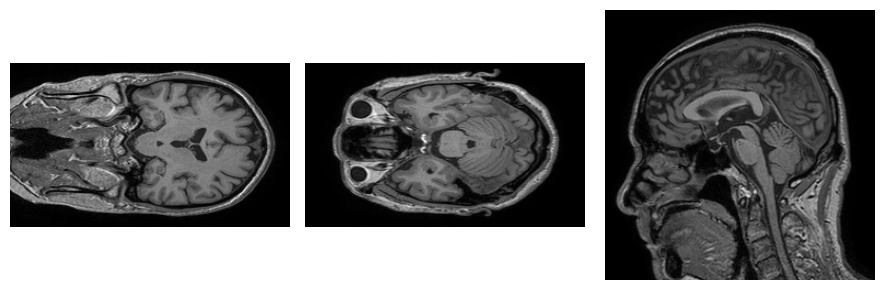

In [6]:
plot(t1w_path)

Create an output directory to store all the outputs

In [7]:
! mkdir -p outputs
! mkdir -p outputs/preprocessing

## Inference

Run the `mri2pet` command on this input MRI. This command allow you to set different hyperparameters:

- `ddim_n` is the number of denoising steps in the reverse process using the DDIM sampler
- `m` is the number of inference repeats in the Latent Average Stabilization (LAS) algorithm

In [8]:
cmd = f"""
mri2pet \
  --i "{t1w_path}" \
  --o "outputs/suvr.nii.gz" \
  --device "cuda" \
  --m 4 \
  --ddim_n 50 \
  --preprocess \
  --preprocess_out "outputs/preprocessing"
"""

!bash -lc "$cmd"

╭────────────────────────────────── CoCoLIT ───────────────────────────────────╮
│                                                                              │
│                                                                              │
│       If you use this work for your research, please cite:                   │
│                                                                              │
│       "CoCoLIT: ControlNet-Conditioned Latent Image Translation for MRI to   │
│   Amyloid PET Synthesis."                                                    │
│       Alec Sargood*, Lemuel Puglisi*, James Cole, Neil Oxtoby, Daniele       │
│   Ravì, Daniel C. Alexander                                                  │
│       *Joint first authors.                                                  │
│                                                                              │
│                                                                              │
╰───────────────────────────

Let's check the output directory:

In [9]:
! ls outputs

preprocessing  suvr.nii.gz


As you can see, setting `--preprocess_out` saves the intermediate files. This is particularly useful when debugging the pipeline results.

In [10]:
! ls outputs/preprocessing

brain_mni_space.nii.gz	 mask_mni_space.nii.gz	 norm_mni_space.nii.gz
brain_orig_space.nii.gz  mask_orig_space.nii.gz


Let's visualize the results:

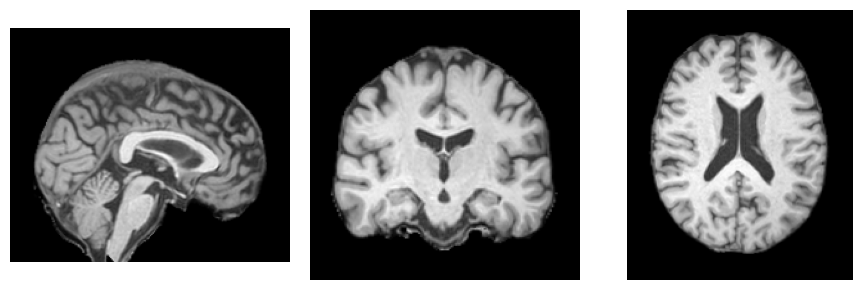

In [11]:
plot("outputs/preprocessing/norm_mni_space.nii.gz")


Visualize the generated amyloid SUVR:

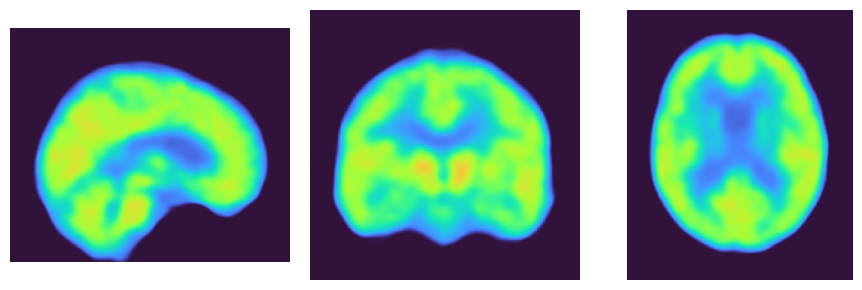

In [12]:
plot("outputs/suvr.nii.gz", input_cmap="turbo", input_range=(0,3))

Visualize the SUVR overlayed onto the T1w image:

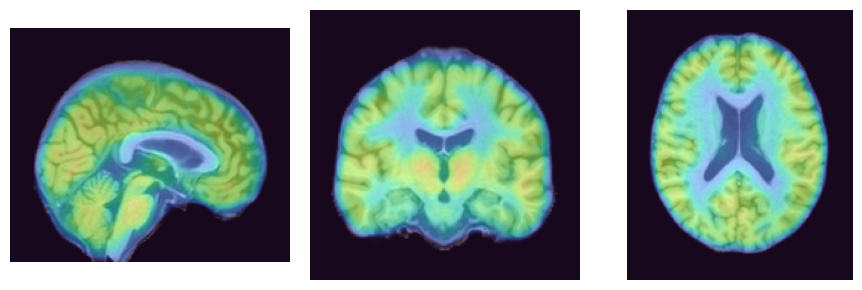

In [13]:
plot(
    input="outputs/preprocessing/norm_mni_space.nii.gz",
    overlay="outputs/suvr.nii.gz", overlay_cmap="turbo", overlay_range=(0,3),
)